### Dependencies

In [128]:
import os
import sys

%load_ext autoreload
%autoreload 2

parent_dir = os.path.split(os.getcwd())[0]
parent_dir

if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    print("Parent dir has been added to sys path.")
else:
    print("Parent dir already exists in sys path")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Parent dir already exists in sys path


In [129]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore')

### Binary Classification With Overfitting Reduction

In [130]:
df = pd.read_csv("../data/raw/labeled_full_stock_news.csv")
original_columns = df.columns.tolist()
print(f"Original columns: {original_columns}")

if df.columns[0].startswith('Unnamed'):
    df = df.drop(df.columns[0], axis=1)

df = df.rename(columns={"headline": "text", "importance": "labels", "label": "sentiment"})
if "labels" in df.columns:
    df["labels"] = df["labels"].str.strip()

labeled_df = df[df["labels"].notna()].copy()
unlabeled_df = df[df["labels"].isna()].copy()

print(f"\nOriginal data:")
print(f"  Labeled samples: {len(labeled_df)}")
print(f"  Unlabeled samples: {len(unlabeled_df)}")
print(f"\nOriginal 3-class distribution:")
print(labeled_df["labels"].value_counts())


Original columns: ['Unnamed: 0', 'headline', 'label', 'importance']

Original data:
  Labeled samples: 2000
  Unlabeled samples: 24000

Original 3-class distribution:
labels
non-major    1380
major         620
Name: count, dtype: int64


In [131]:
def convert_to_binary(label):
    if pd.isna(label):
        return np.nan
    label = label.lower().strip()
    if label == 'major':
        return 1
    else:
        return 0

labeled_df["binary_label"] = labeled_df["labels"].apply(convert_to_binary)

print(f"\nBinary label distribution:")
print(f"  Class 0 (non-major): {(labeled_df['binary_label']==0).sum()}")
print(f"  Class 1 (major): {(labeled_df['binary_label']==1).sum()}")


Binary label distribution:
  Class 0 (non-major): 1380
  Class 1 (major): 620


In [132]:
train_df, test_df = train_test_split(
    labeled_df,
    test_size=0.2,
    random_state=42,
    stratify=labeled_df["binary_label"]
)

def clean_text(text):
    text = str(text).replace("\n", " ")
    text = " ".join(text.split())
    return text

train_df["text"] = train_df["text"].apply(clean_text)
test_df["text"] = test_df["text"].apply(clean_text)
unlabeled_df["text"] = unlabeled_df["text"].apply(clean_text)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
unlabeled_df = unlabeled_df.reset_index(drop=True)

print(f"\nSplit:")
print(f"  Training: {len(train_df)}")
print(f"  Test: {len(test_df)}")
print(f"  Unlabeled: {len(unlabeled_df)}")



Split:
  Training: 1600
  Test: 400
  Unlabeled: 24000


In [133]:
vectorizer = TfidfVectorizer(
    max_features=2000,      
    ngram_range=(1, 2),     
    min_df=3,               
    max_df=0.7,             
    sublinear_tf=True,
    strip_accents='unicode',
    lowercase=True
)

X_train = vectorizer.fit_transform(train_df['text'])
X_test = vectorizer.transform(test_df['text'])
X_unlabeled = vectorizer.transform(unlabeled_df['text'])

y_train = train_df['binary_label'].values
y_test = test_df['binary_label'].values

print(f"\nFeature matrix shapes:")
print(f"  Train: {X_train.shape}")
print(f"  Test: {X_test.shape}")
print(f"  Unlabeled: {X_unlabeled.shape}")


Feature matrix shapes:
  Train: (1600, 1693)
  Test: (400, 1693)
  Unlabeled: (24000, 1693)


In [134]:
c_values = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
best_c = 0.5
best_gap = float('inf')
results = []

for c in c_values:
    model = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        C=c,
        random_state=42,
        penalty='l2'
    )

    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    gap = train_acc - test_acc

    results.append({
        'C': c,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'gap': gap
    })

    print(f"C={c:.1f}: Train={train_acc:.4f}, Test={test_acc:.4f}, Gap={gap:.4f}")

    if gap < best_gap and test_acc > 0.60:
        best_gap = gap
        best_c = c

print(f"\nBest C value: {best_c} (Gap: {best_gap:.4f})")

C=0.1: Train=0.9125, Test=0.9275, Gap=-0.0150
C=0.2: Train=0.9313, Test=0.9425, Gap=-0.0112
C=0.3: Train=0.9463, Test=0.9525, Gap=-0.0062
C=0.5: Train=0.9569, Test=0.9625, Gap=-0.0056
C=0.7: Train=0.9637, Test=0.9675, Gap=-0.0038
C=1.0: Train=0.9706, Test=0.9675, Gap=0.0031

Best C value: 0.1 (Gap: -0.0150)


#### Ensemble Learning

In [135]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=best_c,
    random_state=42,
    penalty='l2'
)

nb_model = MultinomialNB(alpha=0.5)

svm_base = LinearSVC(
    max_iter=2000,
    class_weight='balanced',
    C=0.3,
    random_state=42,
    dual=False
)

svm_model = CalibratedClassifierCV(svm_base, cv=3)

ensemble = VotingClassifier(
    estimators=[
        ('lr', lr_model),
        ('nb', nb_model),
        ('svm', svm_model)
    ],
    voting='soft',  
    weights=[2, 1, 1] 
)

ensemble.fit(X_train, y_train)

y_pred_train = ensemble.predict(X_train)
y_pred_test = ensemble.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
gap = train_acc - test_acc

print(f"\nENSEMBLE RESULTS:")
print(f"  Training Accuracy: {train_acc:.4f}")
print(f"  Test Accuracy: {test_acc:.4f}")
print(f"  Overfitting Gap: {gap:.4f}")

if gap < 0.15:
    print("Overfitting reduced to acceptable level!")
elif gap < 0.20:
    print("Overfitting improved but still present")
else:
    print("Overfitting still high")


ENSEMBLE RESULTS:
  Training Accuracy: 0.9675
  Test Accuracy: 0.9550
  Overfitting Gap: 0.0125
Overfitting reduced to acceptable level!


#### Cross Validation

Cross-validation scores: [0.925    0.934375 0.91875  0.915625 0.928125]
Mean CV Accuracy: 0.9244 (+/- 0.0133)
Test Accuracy: 0.9550

Test Set Classification Report:
              precision    recall  f1-score   support

   non-major     0.9448    0.9928    0.9682       276
       major     0.9818    0.8710    0.9231       124

    accuracy                         0.9550       400
   macro avg     0.9633    0.9319    0.9456       400
weighted avg     0.9563    0.9550    0.9542       400



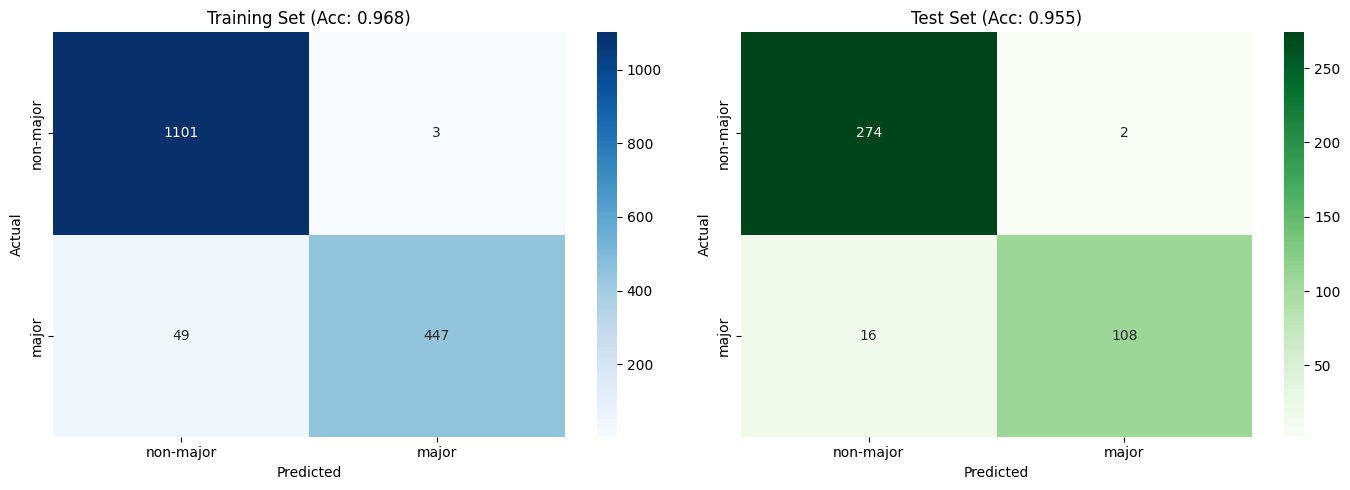


COMPARISON: DIFFERENT APPROACHES


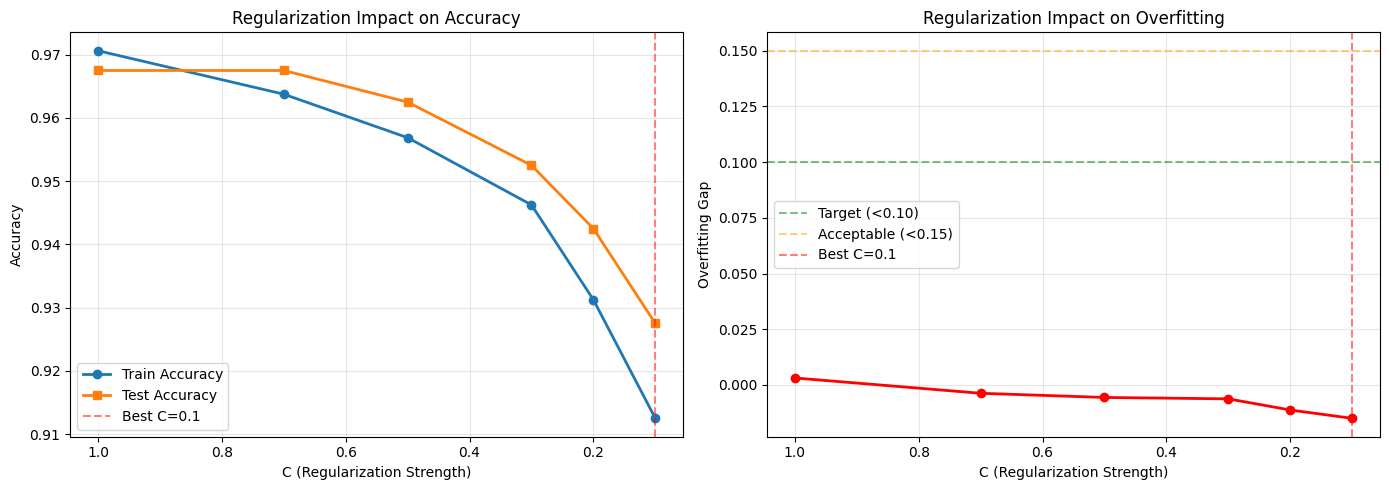


PREDICTING UNLABELED DATA

Predictions for 24000 unlabeled samples:
  Non-major: 19746 (82.3%)
  Major: 4254 (17.7%)

Confidence distribution:
count    24000.000000
mean         0.743036
std          0.075614
min          0.500004
25%          0.709244
50%          0.759077
75%          0.790700
max          0.937920
Name: confidence, dtype: float64

Low confidence predictions (<0.6): 1537

Sample of low-confidence predictions:
                                                 text label_name  confidence
23  Gap stock plummets after retailer slashes sale...  non-major    0.545566
40  Dow Jones Sells Off After Stock Market Bounce;...  non-major    0.538608
51  ADP National Employment Report: Private Sector...  non-major    0.524520
60  U.S. SEC rejects Grayscale's spot bitcoin ETF ...      major    0.566988
62  Wells Fargo experts: Here's how Orlando busine...      major    0.503816


In [136]:
cv_scores = cross_val_score(ensemble, X_train, y_train, cv=5, scoring='accuracy')

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Test Accuracy: {test_acc:.4f}")

print("\nTest Set Classification Report:")
print(classification_report(y_test, y_pred_test,
                          target_names=['non-major', 'major'],
                          digits=4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_train = confusion_matrix(y_train, y_pred_train)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['non-major', 'major'],
            yticklabels=['non-major', 'major'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Training Set (Acc: {train_acc:.3f})')

cm_test = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['non-major', 'major'],
            yticklabels=['non-major', 'major'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'Test Set (Acc: {test_acc:.3f})')

plt.tight_layout()
plt.show()

print("\nCOMPARISON: DIFFERENT APPROACHES")

results_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['C'], results_df['train_acc'],
            marker='o', label='Train Accuracy', linewidth=2)
axes[0].plot(results_df['C'], results_df['test_acc'],
            marker='s', label='Test Accuracy', linewidth=2)
axes[0].axvline(x=best_c, color='r', linestyle='--', alpha=0.5, label=f'Best C={best_c}')
axes[0].set_xlabel('C (Regularization Strength)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Regularization Impact on Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].invert_xaxis()

axes[1].plot(results_df['C'], results_df['gap'],
            marker='o', color='red', linewidth=2)
axes[1].axhline(y=0.1, color='g', linestyle='--', alpha=0.5, label='Target (<0.10)')
axes[1].axhline(y=0.15, color='orange', linestyle='--', alpha=0.5, label='Acceptable (<0.15)')
axes[1].axvline(x=best_c, color='r', linestyle='--', alpha=0.5, label=f'Best C={best_c}')
axes[1].set_xlabel('C (Regularization Strength)')
axes[1].set_ylabel('Overfitting Gap')
axes[1].set_title('Regularization Impact on Overfitting')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].invert_xaxis()

plt.tight_layout()
plt.show()

print("\nPREDICTING UNLABELED DATA")

unlabeled_predictions = ensemble.predict(X_unlabeled)
unlabeled_proba = ensemble.predict_proba(X_unlabeled)

unlabeled_df['binary_label'] = unlabeled_predictions
unlabeled_df['confidence'] = unlabeled_proba.max(axis=1)
unlabeled_df['label_name'] = unlabeled_df['binary_label'].map({
    0: 'non-major',
    1: 'major'
})

print(f"\nPredictions for {len(unlabeled_df)} unlabeled samples:")
print(f"  Non-major: {(unlabeled_predictions == 0).sum()} ({100*(unlabeled_predictions == 0).sum()/len(unlabeled_predictions):.1f}%)")
print(f"  Major: {(unlabeled_predictions == 1).sum()} ({100*(unlabeled_predictions == 1).sum()/len(unlabeled_predictions):.1f}%)")

print(f"\nConfidence distribution:")
print(unlabeled_df['confidence'].describe())

low_conf_threshold = 0.6
low_conf = unlabeled_df[unlabeled_df['confidence'] < low_conf_threshold]
print(f"\nLow confidence predictions (<{low_conf_threshold}): {len(low_conf)}")
if len(low_conf) > 0:
    print("\nSample of low-confidence predictions:")
    print(low_conf[['text', 'label_name', 'confidence']].head())

#### Saving Labeled Data

In [137]:
print("SAVING LABELED DATA")

original_df = pd.read_csv("../data/raw/labeled_full_stock_news.csv")

if original_df.columns[0].startswith('Unnamed'):
    original_df = original_df.drop(original_df.columns[0], axis=1)

print(f"Original CSV columns: {original_df.columns.tolist()}")

original_df['text_clean'] = original_df['headline'].apply(clean_text)

text_to_prediction = {}

for _, row in train_df.iterrows():
    text_to_prediction[row['text']] = {
        'binary_label': row['binary_label'],
        'confidence': 1.0,
        'source': 'original_labeled'
    }

for _, row in test_df.iterrows():
    text_to_prediction[row['text']] = {
        'binary_label': row['binary_label'],
        'confidence': 1.0,
        'source': 'original_labeled'
    }

for _, row in unlabeled_df.iterrows():
    if 'binary_label' in row and 'confidence' in row:
        text_to_prediction[row['text']] = {
            'binary_label': row['binary_label'],
            'confidence': row['confidence'],
            'source': 'predicted'
        }

original_df['binary_label'] = original_df['text_clean'].map(
    lambda x: text_to_prediction.get(x, {}).get('binary_label', np.nan)
)
original_df['confidence'] = original_df['text_clean'].map(
    lambda x: text_to_prediction.get(x, {}).get('confidence', np.nan)
)
original_df['source'] = original_df['text_clean'].map(
    lambda x: text_to_prediction.get(x, {}).get('source', 'unknown')
)

original_df['label_name'] = original_df['binary_label'].map({
    0: 'non-major',
    1: 'major'
})

original_df = original_df.drop('text_clean', axis=1)

output_filename = '../data/complete_labeled_dataset.csv'
original_df.to_csv(output_filename, index=False)

print(f"\nComplete labeled dataset saved to '{output_filename}'")
print(f"\nDataset summary:")
print(f"  Total samples: {len(original_df)}")
print(f"  Original labeled: {len(train_df) + len(test_df)}")
print(f"  Newly predicted: {len(unlabeled_df)}")

print(f"\nOutput columns: {original_df.columns.tolist()}")
print(f"\nOverall label distribution:")
print(original_df['label_name'].value_counts())
print(f"\nSource distribution:")
print(original_df['source'].value_counts())

print(f"\nSample of saved data (first 5 rows in original order):")
display_cols = ['headline', 'label_name', 'confidence', 'source']
if 'sentiment' in original_df.columns:
    display_cols.insert(1, 'sentiment')
if 'Importance' in original_df.columns:
    display_cols.insert(2, 'Importance')

available_cols = [col for col in display_cols if col in original_df.columns]
print(original_df[available_cols].head())

print(f"\nRow order and all columns match original CSV file!")
print(f"   Original CSV shape: {original_df.shape}")


SAVING LABELED DATA
Original CSV columns: ['headline', 'label', 'importance']

Complete labeled dataset saved to '../data/complete_labeled_dataset.csv'

Dataset summary:
  Total samples: 26000
  Original labeled: 2000
  Newly predicted: 24000

Output columns: ['headline', 'label', 'importance', 'binary_label', 'confidence', 'source', 'label_name']

Overall label distribution:
label_name
non-major    21126
major         4874
Name: count, dtype: int64

Source distribution:
source
predicted           24000
original_labeled     2000
Name: count, dtype: int64

Sample of saved data (first 5 rows in original order):
                                            headline label_name  confidence  \
0  Markets Close Mostly Lower Again; ROST, PANW R...      major         1.0   
1  Gap plummets on earnings miss, cuts full-year ...      major         1.0   
2  Billionaire Ken Fisher is Selling These 10 Stocks  non-major         1.0   
3          Corning net income drops 13%, shares fall  non-major    

In [138]:
print("\nFINAL SUMMARY")

print(f"\nMODEL PERFORMANCE:")
print(f"  Training Accuracy: {train_acc:.4f}")
print(f"  Test Accuracy: {test_acc:.4f}")
print(f"  CV Mean Accuracy: {cv_scores.mean():.4f}")
print(f"  Overfitting Gap: {gap:.4f}")

if gap < 0.10:
    print(f"\nEXCELLENT: Overfitting well controlled (gap < 0.10)")
elif gap < 0.15:
    print(f"\nGOOD: Overfitting acceptable (gap < 0.15)")
elif gap < 0.20:
    print(f"\nMODERATE: Some overfitting present (gap < 0.20)")
else:
    print(f"\nHIGH: Significant overfitting (gap >= 0.20)")


FINAL SUMMARY

MODEL PERFORMANCE:
  Training Accuracy: 0.9675
  Test Accuracy: 0.9550
  CV Mean Accuracy: 0.9244
  Overfitting Gap: 0.0125

EXCELLENT: Overfitting well controlled (gap < 0.10)
